<a href="https://colab.research.google.com/github/EmilioSaulG/Telecom_X/blob/main/telecomx_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X - Análisis de Evasión de Clientes (Churn)

Este proyecto tiene como objetivo analizar los factores que influyen en la evasión de clientes en Telecom X.  
A través de técnicas de análisis de datos en Python se explorarán patrones relacionados con la cancelación del servicio.

El análisis incluye:

- Extracción de datos desde una API
- Proceso ETL (Extracción, Transformación y Carga)
- Limpieza y preparación de datos
- Análisis exploratorio de datos (EDA)
- Visualización de patrones relacionados con churn
- Conclusiones y recomendaciones

## Importación de librerías

En esta sección se importan las bibliotecas necesarias para la manipulación, análisis y visualización de los datos.

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Extracción de datos

Los datos se encuentran disponibles en formato JSON en un repositorio público.  
En este paso se cargan directamente desde la fuente utilizando pandas.

In [119]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = pd.read_json(url)

data.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [120]:
df = pd.json_normalize(data.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [121]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

## Exploración inicial del dataset

Antes de comenzar el análisis es importante conocer la estructura de los datos, los tipos de variables y verificar si existen valores faltantes.

In [122]:
df.shape

(7267, 21)

In [123]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

## Verificación de valores faltantes

Se revisa si existen valores nulos dentro del dataset que puedan afectar el análisis.

In [125]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


## Limpieza de nombres de columnas

Se ajustan los nombres de las columnas para facilitar su uso en el análisis.

In [126]:
df.columns = df.columns.str.replace(".", "_", regex=False)

df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [132]:
df.rename(columns={
    "account_Charges_Monthly": "Charges_Monthly",
    "account_Charges_Total": "Charges_Total",
    "account_Churn": "Churn"
}, inplace=True)

## Revisión de tipos de datos

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

## Conversión de variables numéricas

In [134]:
df["Charges_Total"] = pd.to_numeric(df["Charges_Total"], errors="coerce")

## Verificación de valores faltantes

In [135]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


## Tratamiento de valores faltantes

In [136]:
df["Charges_Total"] = df["Charges_Total"].fillna(0)

## Verificación de duplicados

In [138]:
df.duplicated().sum()

np.int64(0)

## Creación de la variable Cuentas_Diarias

In [139]:
df["Cuentas_Diarias"] = df["Charges_Monthly"] / 30

## Transformación de variable churn

In [140]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

## Análisis descriptivo

In [141]:
df.describe()

,Churn,customer_SeniorCitizen,customer_tenure,Charges_Monthly,Charges_Total,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098,2277.182035,2.157337
std,0.441561,0.369074,24.571773,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,9.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,29.000000,70.300000,1389.200000,2.343333
75%,1.000000,0.000000,55.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


## Distribución de evasión de clientes

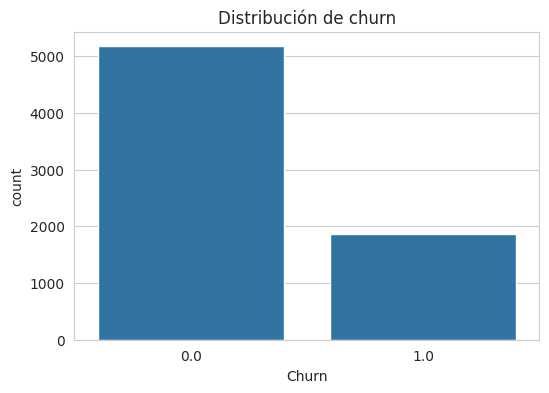

In [142]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Distribución de churn")

plt.show()

## Churn según tipo de contrato

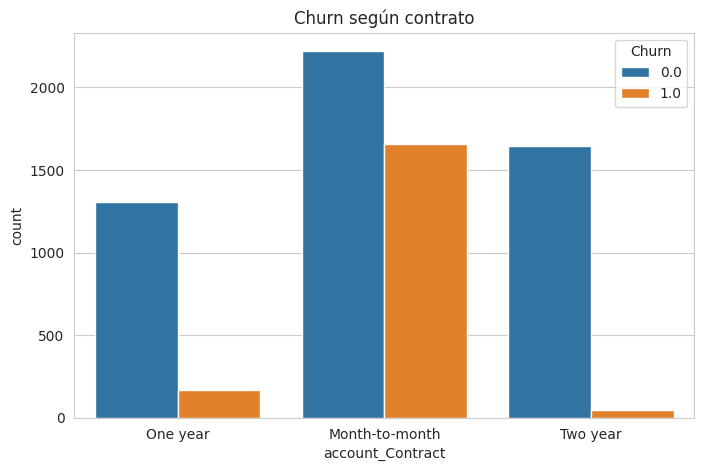

In [143]:
plt.figure(figsize=(8,5))

sns.countplot(x="account_Contract", hue="Churn", data=df)

plt.title("Churn según contrato")

plt.show()

## Relación entre churn y gasto mensual

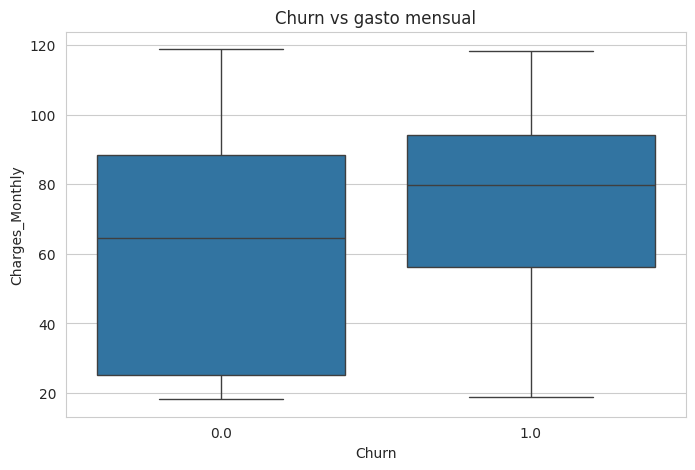

In [144]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="Charges_Monthly", data=df)

plt.title("Churn vs gasto mensual")

plt.show()


## Churn según permanencia

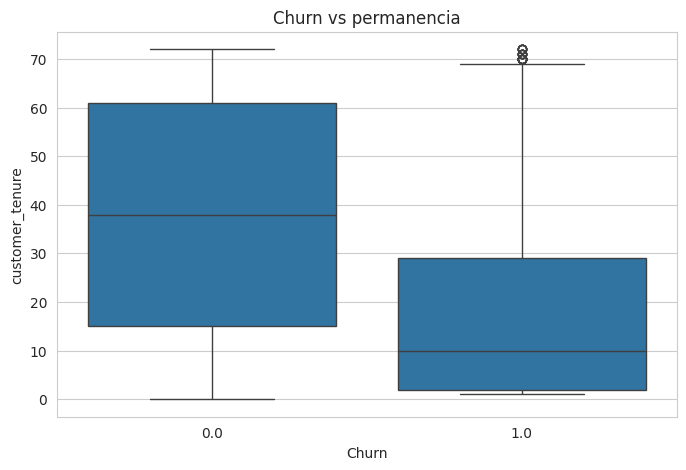

In [145]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="customer_tenure", data=df)

plt.title("Churn vs permanencia")

plt.show()

## Correlación entre variables

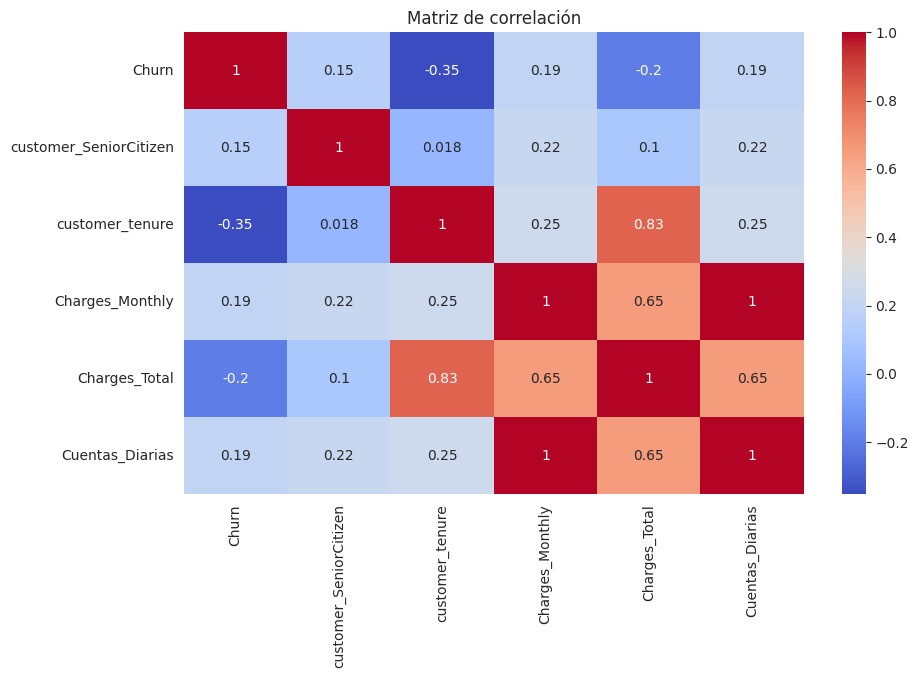

In [146]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

## Churn según método de pago

En este gráfico se analiza la distribución de churn según el método de pago utilizado por los clientes.
Esto permite observar si ciertos métodos de pago están asociados con una mayor tasa de cancelación.

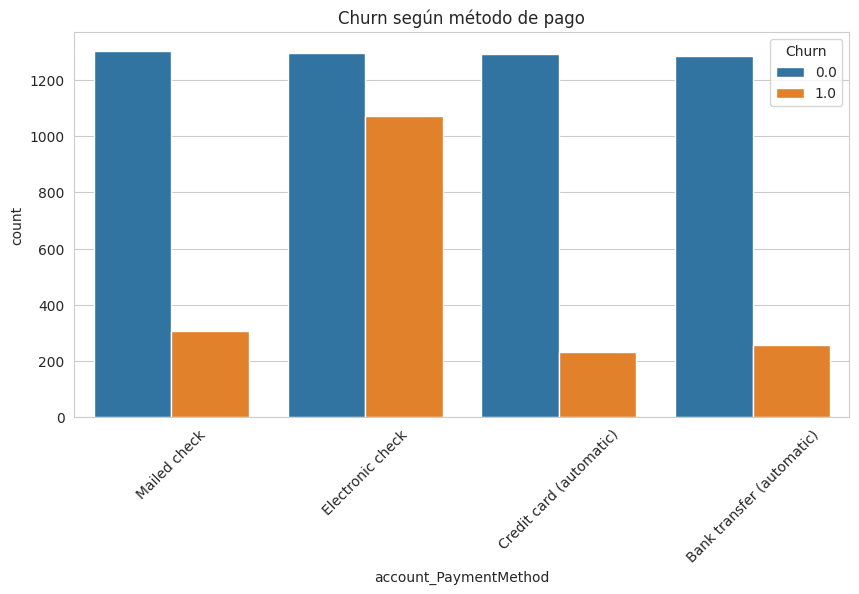

In [147]:
plt.figure(figsize=(10,5))

sns.countplot(x="account_PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=45)
plt.title("Churn según método de pago")

plt.show()

## Churn según servicio de internet

Se analiza cómo se distribuye la evasión de clientes dependiendo del tipo de servicio de internet contratado.

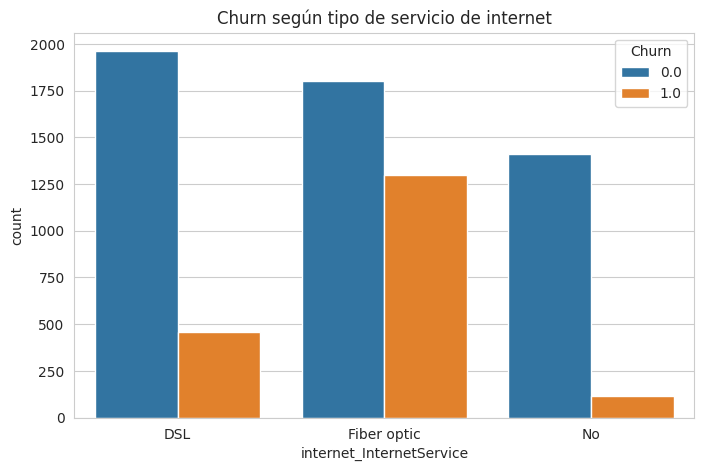

In [148]:
plt.figure(figsize=(8,5))

sns.countplot(x="internet_InternetService", hue="Churn", data=df)

plt.title("Churn según tipo de servicio de internet")

plt.show()

## Relación entre churn y gasto diario

Se analiza cómo se distribuye el gasto diario de los clientes que cancelaron el servicio frente a los que permanecen.

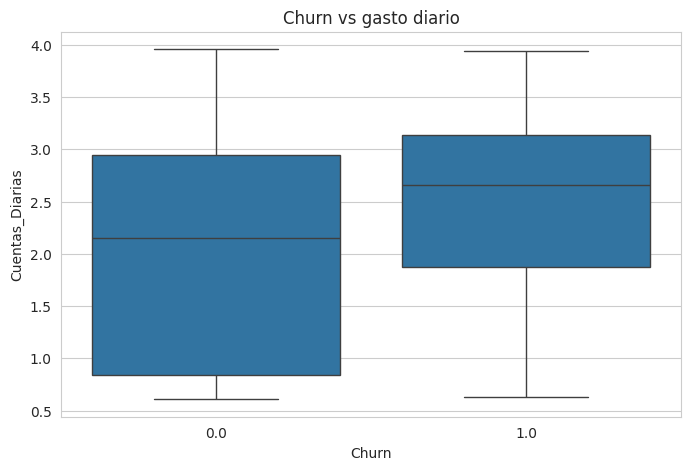

In [149]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="Cuentas_Diarias", data=df)

plt.title("Churn vs gasto diario")

plt.show()

## Conclusiones

A partir del análisis exploratorio de los datos se identificaron varios patrones que pueden estar relacionados con la evasión de clientes en Telecom X.

Uno de los factores más relevantes parece ser el tipo de contrato. Los clientes que cuentan con contratos de corto plazo presentan una mayor proporción de cancelaciones en comparación con aquellos que tienen contratos de mayor duración. Esto puede indicar que los contratos más largos generan mayor estabilidad y compromiso con el servicio.

También se observó que el tiempo de permanencia del cliente está relacionado con la probabilidad de churn. Los clientes con menor tiempo en la compañía muestran una mayor tendencia a cancelar el servicio, lo que sugiere que las primeras etapas de la relación con el cliente pueden ser críticas para su retención.

En cuanto a la facturación, tanto el gasto mensual como el gasto diario muestran diferencias entre los clientes que cancelaron y los que permanecen. Esto podría indicar que el costo del servicio o la percepción del valor recibido influyen en la decisión de continuar o cancelar el servicio.

Además, algunas variables relacionadas con servicios contratados y métodos de pago presentan diferencias en la distribución del churn, lo cual podría ser útil para identificar segmentos de clientes con mayor riesgo de cancelación.

En general, el análisis permite identificar ciertos patrones que pueden servir como punto de partida para desarrollar estrategias de retención más efectivas.


## Recomendaciones

A partir de los resultados obtenidos durante el análisis exploratorio de los datos, se pueden proponer algunas acciones que podrían ayudar a reducir la evasión de clientes en Telecom X.

### 1. Implementar modelos predictivos de churn

El análisis exploratorio permite identificar patrones iniciales en el comportamiento de los clientes. Sin embargo, un siguiente paso importante sería desarrollar modelos de Machine Learning capaces de predecir qué clientes tienen mayor probabilidad de cancelar el servicio.

Modelos como regresión logística, árboles de decisión o Random Forest podrían utilizarse para identificar clientes en riesgo y permitir a la empresa actuar de manera preventiva.

---

### 2. Fortalecer estrategias de retención para clientes nuevos

El análisis sugiere que los clientes con menor tiempo de permanencia en la empresa presentan una mayor tendencia a cancelar el servicio.

Por esta razón, la empresa podría implementar estrategias enfocadas en los primeros meses de relación con el cliente, como programas de fidelización, promociones iniciales o seguimiento personalizado para mejorar la experiencia del usuario.

---

### 3. Analizar la relación entre precios y cancelación

Las variables relacionadas con la facturación mensual y el gasto diario pueden ofrecer información importante sobre la percepción de valor por parte de los clientes.

Telecom X podría evaluar si ciertos planes de servicio presentan niveles más altos de cancelación y considerar ajustes en la estructura de precios o en los beneficios incluidos en cada plan.

---

### 4. Evaluar combinaciones de servicios contratados

Muchos clientes contratan múltiples servicios dentro de la empresa, como internet, soporte técnico o plataformas de streaming.

Analizar qué combinaciones de servicios presentan menores tasas de cancelación podría ayudar a diseñar paquetes más atractivos y mejorar la satisfacción del cliente.

---

### 5. Segmentar clientes según riesgo de churn

Una estrategia útil podría ser segmentar a los clientes según su probabilidad de cancelar el servicio.

Por ejemplo, se podrían identificar grupos como:

- clientes con alto riesgo de cancelación
- clientes con riesgo medio
- clientes con bajo riesgo

Esto permitiría aplicar estrategias específicas de retención para cada segmento y optimizar los recursos de la empresa.

---

## Trabajo futuro

Este análisis exploratorio representa un primer paso para comprender los factores asociados con la evasión de clientes en Telecom X. Como continuación del proyecto, se podrían desarrollar nuevas líneas de análisis, tales como:

- construcción de modelos predictivos de churn
- análisis de correlación entre variables
- segmentación de clientes mediante técnicas de clustering
- desarrollo de dashboards interactivos para monitorear métricas clave

1 Introducción  
2 Importación de datos  
3 Exploración inicial  
4 Limpieza de datos  
5 Transformación de variables  
6 Análisis exploratorio  
7 Visualizaciones  
8 Conclusiones  
9 Recomendaciones  
10 Trabajo futuro